In [2]:
from sklearn.model_selection    import train_test_split
from sklearn.ensemble           import RandomForestRegressor
from xgboost                    import XGBRegressor
from sklearn.metrics            import mean_absolute_error, mean_squared_error, r2_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = r"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Churn Predictor and LTV\data\processed\churn_feature_data.csv"
df = pd.read_csv(path)

X = df.drop(columns=["Churn", "CustomerID", "FutureLTV_12M"])
y = df["FutureLTV_12M"]

# Condificación One-Hot para variables categóricas y (False) mantener la explicabilidad
X = pd.get_dummies(X, drop_first=False)

# Tenemos dos tipos de estratificación porque nuestra "y" tiene asimetría
# 1. Estratificación por Churn (Abandono [0,1])
# stratify = df["Churn"]
# 2. Estratificación por rangos en dólares
# y_bins = pd.qcut(y, q=4, labels=False) 
# stratify = y_bins

y_bins = pd.qcut(x=y, q=4, labels=False)

# Split de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y_bins)

# Entrenamiento del Modelo Regresor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, criterion="squared_error").fit(X_train, y_train)
xgb_reg = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, learning_rate=0.05).fit(X_train, y_train)

# Predicción
y_hat_rf_reg = rf_reg.predict(X_test)
y_hat_xgb_reg = xgb_reg.predict(X_test)

# Métricas Random Forest
mae_rf = mean_squared_error(y_test, y_hat_rf_reg)
r2_rf = r2_score(y_test, y_hat_rf_reg)

# Métricas XGBOOST
mae_xgb = mean_squared_error(y_test, y_hat_xgb_reg)
r2_xgb = r2_score(y_test, y_hat_xgb_reg)

# Print Resultados
print("="*60)
print("Evaluación de Modelos de Regresión para LTV por 12 meses")
print(f"Random Forest   -> MAE: ${mae_rf:,.2f} | R2: {r2_rf:.4%}")
print(f"XGBoost         -> MAE: ${mae_xgb:,.2f} | R2: {r2_xgb:.4%}")
print("="*60)

Evaluación de Modelos de Regresión para LTV por 12 meses
Random Forest   -> MAE: $57,779.34 | R2: 55.0746%
XGBoost         -> MAE: $58,407.61 | R2: 54.5861%


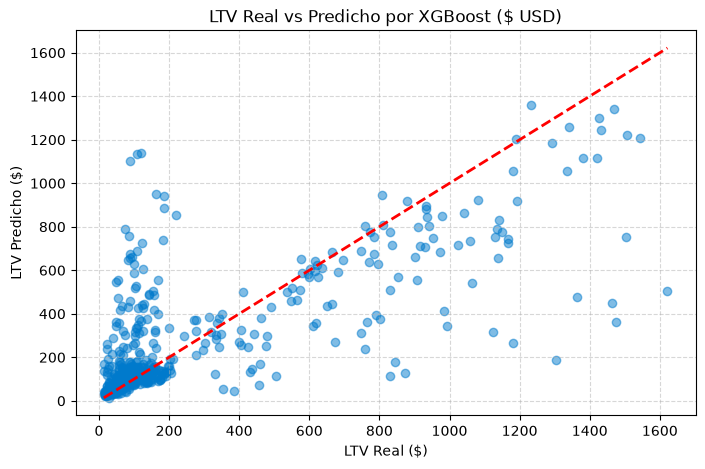

In [4]:
# Gráfico Real vs Predicho para XGBoost
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_hat_xgb_reg, alpha=0.5, color='#007acc')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('LTV Real vs Predicho por XGBoost ($ USD)')
plt.xlabel('LTV Real ($)')
plt.ylabel('LTV Predicho ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()